In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import arviz as az
from mfvi import run_mfvi
from ssvi_i import run_ssvi_i
from ssvi_c import run_ssvi_c
from gibbs import run_gibbs
from gibbs_og import run_gibbs_og
from data_prep import prep_data
from results import (
    sample_from_mfvi, sample_from_ssvi_i, sample_from_ssvi_c,
    compute_cov_true, extract_cov_mfvi, UQF, compute_uqf,
    prepare_gibbs_faes_arrays, compute_faes_scores, plot_accuracy_boxplots,
    compute_irfs, plot_irfs_comparison,
    compute_wasserstein_curve, plot_wasserstein_grid_comparison,
)

In [2]:
"""Data Loading"""

# selecting variables and dates
columns_wanted = ["lnipsa", "lncpi", "r-mkt", "lndem"]
start_date = "1987-01"
end_date = "1998-12"
# setting lags, number of variables, etc
L = 6
C = 5
T = len(pd.date_range(start=start_date, end=end_date, freq="MS"))
N = 4
N_w = 3
N_z = 3
L_w = [0,1]
L_z1 = [1,2]
L_z2 = [0,1]
K = N*L + N_w*len(L_w)
n_lag_z = len(L_z1)  # == len(L_z2)
Z_width = N_z * n_lag_z

# loading data
def load_and_filter(path, columns_wanted):
    df = pd.read_csv(path, index_col=0)
    df.index = pd.to_datetime(df.index, format="%Y-%m")
    df = df[columns_wanted]
    load_start = pd.Timestamp(start_date) - pd.DateOffset(months=L)
    df = df.loc[load_start:end_date]
    return df

fin = load_and_filter("Jarocinski Data/mj-data/2008-euro/finland.csv", columns_wanted)
fra = load_and_filter("Jarocinski Data/mj-data/2008-euro/france.csv", columns_wanted)
ita = load_and_filter("Jarocinski Data/mj-data/2008-euro/italy.csv", columns_wanted)
por = load_and_filter("Jarocinski Data/mj-data/2008-euro/portugal.csv", columns_wanted)
spa = load_and_filter("Jarocinski Data/mj-data/2008-euro/spain.csv", columns_wanted)

wor = load_and_filter("Jarocinski Data/mj-data/2008-world/world1.csv", ["ffr", "lnoil-eur", "lnnfd-eur"])
ger1 = load_and_filter("Jarocinski Data/mj-data/2008-world/world1.csv", ["lnipsa-ger"])
ger2 = load_and_filter("Jarocinski Data/mj-data/2008-world/world1.csv", ["r-mkt-ger", "lneur-usd"])

Y = np.stack([fin.values, fra.values, ita.values, por.values, spa.values], axis=0)
W = wor.values
Z1 = ger1.values
Z2 = ger2.values

In [3]:
"""Data Preprocessing"""

mfvi_pack, ssvi_i_pack, gibbs_pack, gibbs_pack_og = prep_data(Y, W, Z1, Z2, C, N, N_w, T, K, Z_width, L, L_w, L_z1, L_z2)

In [123]:
"""Simulated Data Generation (unused for now)"""
"""
T, C, N, L, W = 100, 6, 3, 2, 1
K = N*L + W
T_sim = T + L

def companion(B, N, L):
    K = N * L
    C = np.zeros((K, K))
    C[:N, :] = B[:, :K]  # exclude w column
    C[N:, :-N] = np.eye(N * (L - 1))
    return C

betas = np.random.normal(0.2, 0.3, size=(C, N, K))
for c in range(C):
    comp = companion(betas[c], N, L)
    radius = np.max(np.abs(np.linalg.eigvals(comp)))
    if radius >= 1:
        betas[c] *= 0.8 / radius

gamma = np.zeros((C, N))
for c in range(C):
    gamma[c] = np.random.normal(c * 0.2 * (-1)**c, 0.1 + c * 0.05, size=N)

# innovations
innovations = np.zeros((T_sim, C, N))
for c in range(C):
    A = np.random.randn(N, N) * 0.1
    Sigma = A @ A.T + np.eye(N) * 0.01
    innovations[:, c, :] = np.random.multivariate_normal(np.zeros(N), Sigma, size=T_sim)

# exogenous variables
z = np.zeros(T_sim)
for t in range(1, T_sim):
    z[t] = 0.7*z[t-1] + np.random.randn()

w = np.zeros(T_sim)
for t in range(1, T_sim):
    w[t] = 0.3*w[t-1] + np.random.randn()

# simulate
Y = np.random.randn(T_sim, C, N)
for t in range(L, T_sim):
    for c in range(C):
        lags = np.concatenate([Y[t-1, c, :], Y[t-2, c, :], [w[t-1]]])
        Y[t, c, :] = betas[c] @ lags + gamma[c]*z[t-1] + innovations[t, c, :]
"""

'\nT, C, N, L, W = 100, 6, 3, 2, 1\nK = N*L + W\nT_sim = T + L\n\ndef companion(B, N, L):\n    K = N * L\n    C = np.zeros((K, K))\n    C[:N, :] = B[:, :K]  # exclude w column\n    C[N:, :-N] = np.eye(N * (L - 1))\n    return C\n\nbetas = np.random.normal(0.2, 0.3, size=(C, N, K))\nfor c in range(C):\n    comp = companion(betas[c], N, L)\n    radius = np.max(np.abs(np.linalg.eigvals(comp)))\n    if radius >= 1:\n        betas[c] *= 0.8 / radius\n\ngamma = np.zeros((C, N))\nfor c in range(C):\n    gamma[c] = np.random.normal(c * 0.2 * (-1)**c, 0.1 + c * 0.05, size=N)\n\n# innovations\ninnovations = np.zeros((T_sim, C, N))\nfor c in range(C):\n    A = np.random.randn(N, N) * 0.1\n    Sigma = A @ A.T + np.eye(N) * 0.01\n    innovations[:, c, :] = np.random.multivariate_normal(np.zeros(N), Sigma, size=T_sim)\n\n# exogenous variables\nz = np.zeros(T_sim)\nfor t in range(1, T_sim):\n    z[t] = 0.7*z[t-1] + np.random.randn()\n\nw = np.zeros(T_sim)\nfor t in range(1, T_sim):\n    w[t] = 0.3*w[

In [ ]:
"""Running MFVI"""
results_mfvi, ELBO_mfvi = run_mfvi(mfvi_pack, Z_width, C, N, K, T)

In [4]:
"""Running SSVI_I"""
results_ssvi_i, ELBO_ssvi_i, ess_list, log_lams_history = run_ssvi_i(ssvi_i_pack, Z_width, C, N, K, T, n_steps=1000, step_size_init = 0.01, s = 0.2, n_burnin = 100)

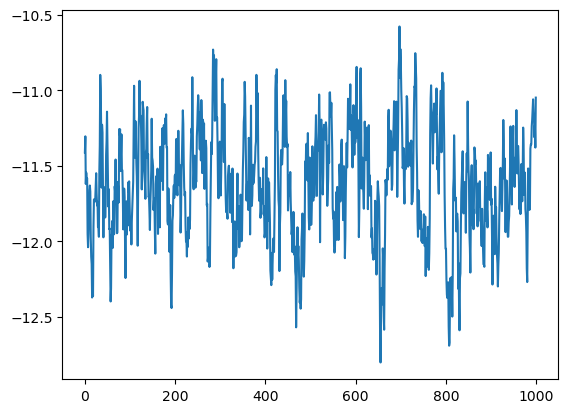

In [5]:
plt.plot(log_lams_history[-1])

In [6]:
"""Running SSVI_C"""
results_ssvi_c, ELBO_ssvi_c, ess_list2, log_lams_history2 = run_ssvi_c(ssvi_i_pack, Z_width, C, N, K, T, n_steps=1000, step_size_init = 1, s = 0.1, n_burnin = 100)

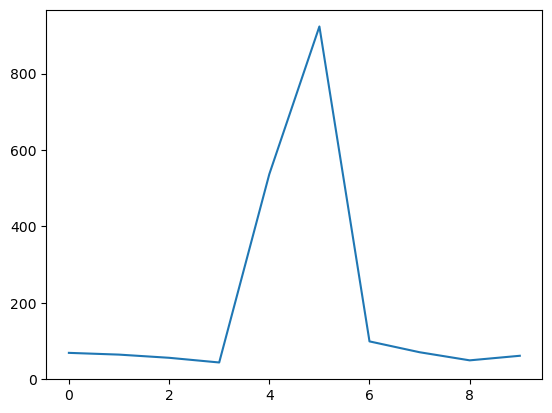

In [30]:
plt.plot(ess_list2)

In [129]:
"""Running Gibbs"""
results_gibbs, ess, rhat = run_gibbs(gibbs_pack, C, N, K, Z_width, T,  n_chains=4, n_steps=10000, n_burnin=2000)

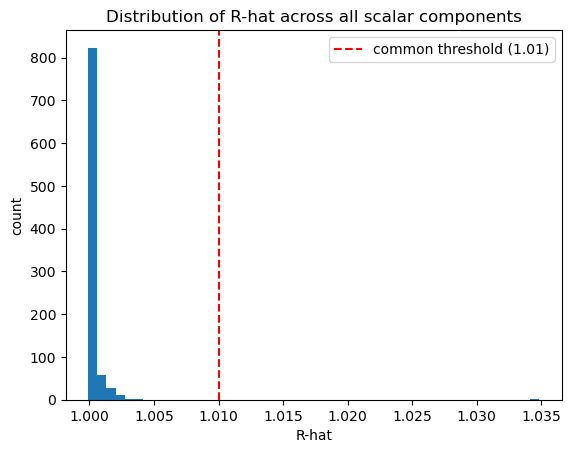

max R-hat: 1.0348
min R-hat: 0.9999
# components with R-hat > 1.01: 1 / 921


In [130]:
plt.hist(rhat, bins=50)
plt.axvline(1.01, color='red', linestyle='--', label='common threshold (1.01)')
plt.xlabel('R-hat')
plt.ylabel('count')
plt.title('Distribution of R-hat across all scalar components')
plt.legend()
plt.show()

print(f"max R-hat: {rhat.max():.4f}")
print(f"min R-hat: {rhat.min():.4f}")
print(f"# components with R-hat > 1.01: {(rhat > 1.01).sum()} / {len(rhat)}")

In [131]:
idx = 0
r_hat_lam = rhat[idx: idx+1]; idx += 1
r_hat_beta0 = rhat[idx: idx+N*K]; idx += N*K
r_hat_betac = rhat[idx: idx+C*N*K]; idx += C*N*K
r_hat_gammac = rhat[idx: idx+C*N*Z_width]; idx += C*N*Z_width
r_hat_sigmac = rhat[idx:]

for name, arr in [('lam', r_hat_lam), ('beta_0', r_hat_beta0), ('beta_c', r_hat_betac),
                   ('gamma_c', r_hat_gammac), ('Sigma_c', r_hat_sigmac)]:
    print(f"{name}: max={arr.max():.3f}, mean={arr.mean():.3f}, frac>1.01={100*(arr>1.01).mean():.1f}%")

lam: max=1.035, mean=1.035, frac>1.01=100.0%
beta_0: max=1.002, mean=1.000, frac>1.01=0.0%
beta_c: max=1.004, mean=1.000, frac>1.01=0.0%
gamma_c: max=1.002, mean=1.000, frac>1.01=0.0%
Sigma_c: max=1.001, mean=1.000, frac>1.01=0.0%


In [155]:
"""UQF Calculation"""

cov_true = compute_cov_true(results_gibbs, C)
cov_mfvi = extract_cov_mfvi(results_mfvi, mfvi_pack, C)

UQFs_mfvi = compute_uqf(cov_true, cov_mfvi, C)

UQFs_mfvi

[np.float64(0.5367104407789919),
 np.float64(0.4962738009981969),
 np.float64(0.5276917432185301),
 np.float64(0.5491851149656661),
 np.float64(0.6391314767388924)]

In [ ]:
UQFs_ssvi_i = compute_uqf(cov_true, results_ssvi_i['cov_deltac'], C)

UQFs_ssvi_i

[np.float64(0.7014885535509628),
 np.float64(0.67475361153525),
 np.float64(0.7031513101665758),
 np.float64(0.7047109549289995),
 np.float64(0.6975474973566381)]

In [ ]:
UQFs_ssvi_c = compute_uqf(cov_true, results_ssvi_c['cov_deltac'], C)

UQFs_ssvi_c

[np.float64(0.6845060817714841),
 np.float64(0.6931703739177753),
 np.float64(0.6867464434583459),
 np.float64(0.6757995600652097),
 np.float64(0.6840539983064523)]

In [158]:
compute_uqf(cov_true, cov_true, C)

[np.float64(0.9999999999977138),
 np.float64(0.9999999999852973),
 np.float64(0.9999999999955989),
 np.float64(0.9999999999947526),
 np.float64(0.9999999999977902)]

In [135]:
"""Getting samples from MFVI output"""
mfvi_samples = sample_from_mfvi(results_mfvi, mfvi_pack, C, N, K, T)

In [ ]:
"""Getting samples from SSVI-I output"""
ssvi_i_samples = sample_from_ssvi_i(results_ssvi_i, ssvi_i_pack, C, N, K, T)

In [ ]:
"""Getting samples from SSVI-C output"""
ssvi_c_samples = sample_from_ssvi_c(results_ssvi_c, ssvi_i_pack, C, N, K, T)

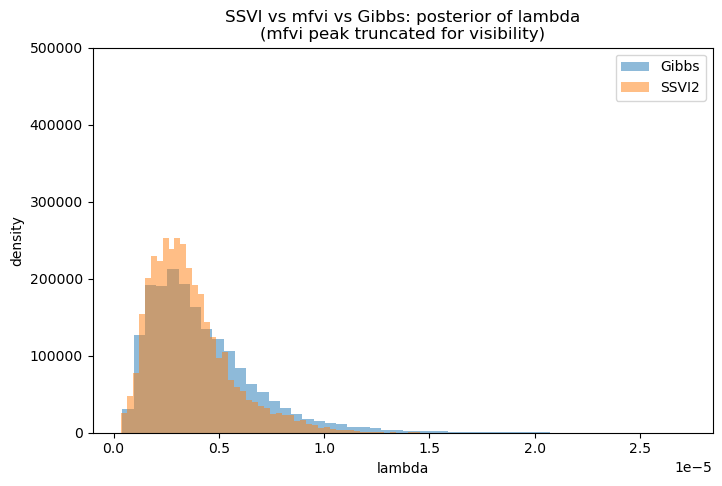

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(results_gibbs['lam'], bins=50, density=True, alpha=0.5, label='Gibbs')
plt.hist(ssvi_i_samples['lam'], bins=50, density=True, alpha=0.5, label='SSVI_I')
plt.hist(ssvi_c_samples['lam'], bins=50, density=True, alpha=0.5, label='SSVI_C')
plt.hist(mfvi_samples['lam'], bins=50, density=True, alpha=0.5, label='mfvi')

plt.ylim(0, 500000)  # cap the y-axis so mfvi's spike is cut off
plt.xlabel('lambda')
plt.ylabel('density')
plt.legend()
plt.title('SSVI-I vs MFVI vs Gibbs: posterior of lambda\n(mfvi peak truncated for visibility)')
plt.show()

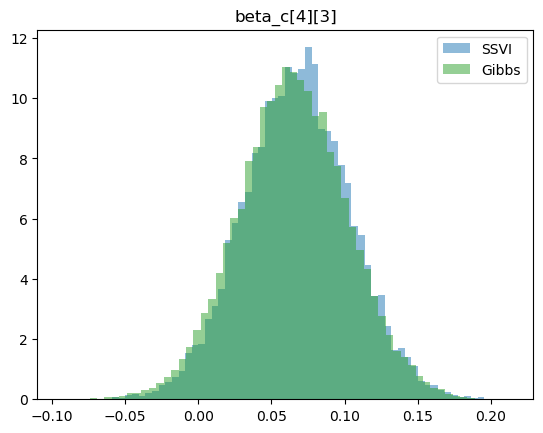

In [ ]:
c, k = 4, 3  # <-- set these

mfvi_arr  = np.array(mfvi_samples['beta_c'])    # (T, C, N*K), do this once outside the loop if reused
ssvi_c_arr  = np.array(ssvi_c_samples['beta_c'])
ssvi_i_arr  = np.array(ssvi_i_samples['beta_c'])
gibbs_arr = np.array(results_gibbs['beta_c'])

plt.hist(mfvi_arr[:, c, k], bins=60, alpha=0.5, density=True, label="mfvi", color="tab:orange")
plt.hist(ssvi_c_arr[:, c, k], bins=60, alpha=0.5, density=True, label="SSVI_C", color="tab:red")
plt.hist(ssvi_i_arr[:, c, k], bins=60, alpha=0.5, density=True, label="SSVI_I", color="tab:blue")
plt.hist(gibbs_arr[:, c, k], bins=60, alpha=0.5, density=True, label="Gibbs", color="tab:green")
plt.legend()
plt.title(f"beta_c[{c}][{k}]")
plt.show()

In [140]:
"""Accuracy Measure (Faes et al. 2011, ter Steege eq. 20)"""

gibbs_faes_arrays = prepare_gibbs_faes_arrays(results_gibbs)

results_faes_mfvi = compute_faes_scores(mfvi_samples, gibbs_faes_arrays)

In [ ]:
results_faes_ssvi_i = compute_faes_scores(ssvi_i_samples, gibbs_faes_arrays)

In [ ]:
results_faes_ssvi_c = compute_faes_scores(ssvi_c_samples, gibbs_faes_arrays)

[autoreload of results failed: Traceback (most recent call last):
  File "c:\Users\krrol\anaconda3\Lib\site-packages\IPython\extensions\autoreload.py", line 276, in check
    superreload(m, reload, self.old_objects)
    ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\krrol\anaconda3\Lib\site-packages\IPython\extensions\autoreload.py", line 475, in superreload
    module = reload(module)
  File "c:\Users\krrol\anaconda3\Lib\importlib\__init__.py", line 129, in reload
    _bootstrap._exec(spec, module)
    ~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 866, in _exec
  File "<frozen importlib._bootstrap_external>", line 1026, in exec_module
  File "<frozen importlib._bootstrap>", line 488, in _call_with_frames_removed
  File "c:\Users\krrol\github-projects\Research-Project\results.py", line 8, in <module>
    from ssvi_i_2 import calc_V_beta02, calc_mu_beta02, calc_V_deltac2, calc_mu_deltac2
ModuleNotFoundError: No module named 'ssvi_i_2'
]


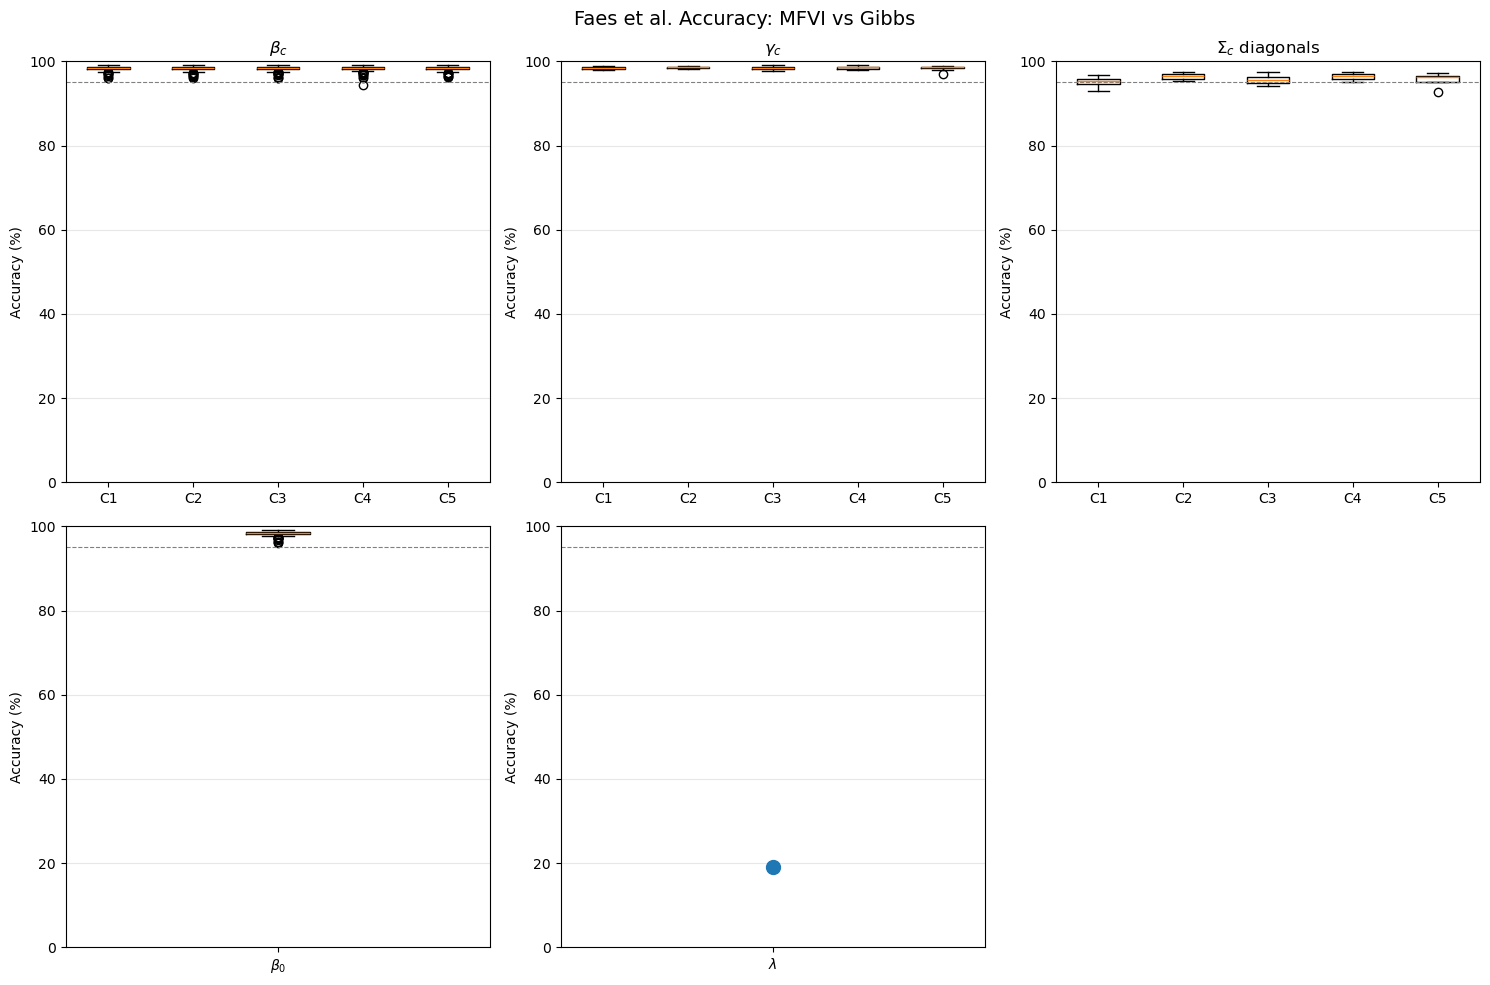

In [296]:
"""Boxplots of Accuracy"""
plot_accuracy_boxplots(results_faes_mfvi, "MFVI", C)

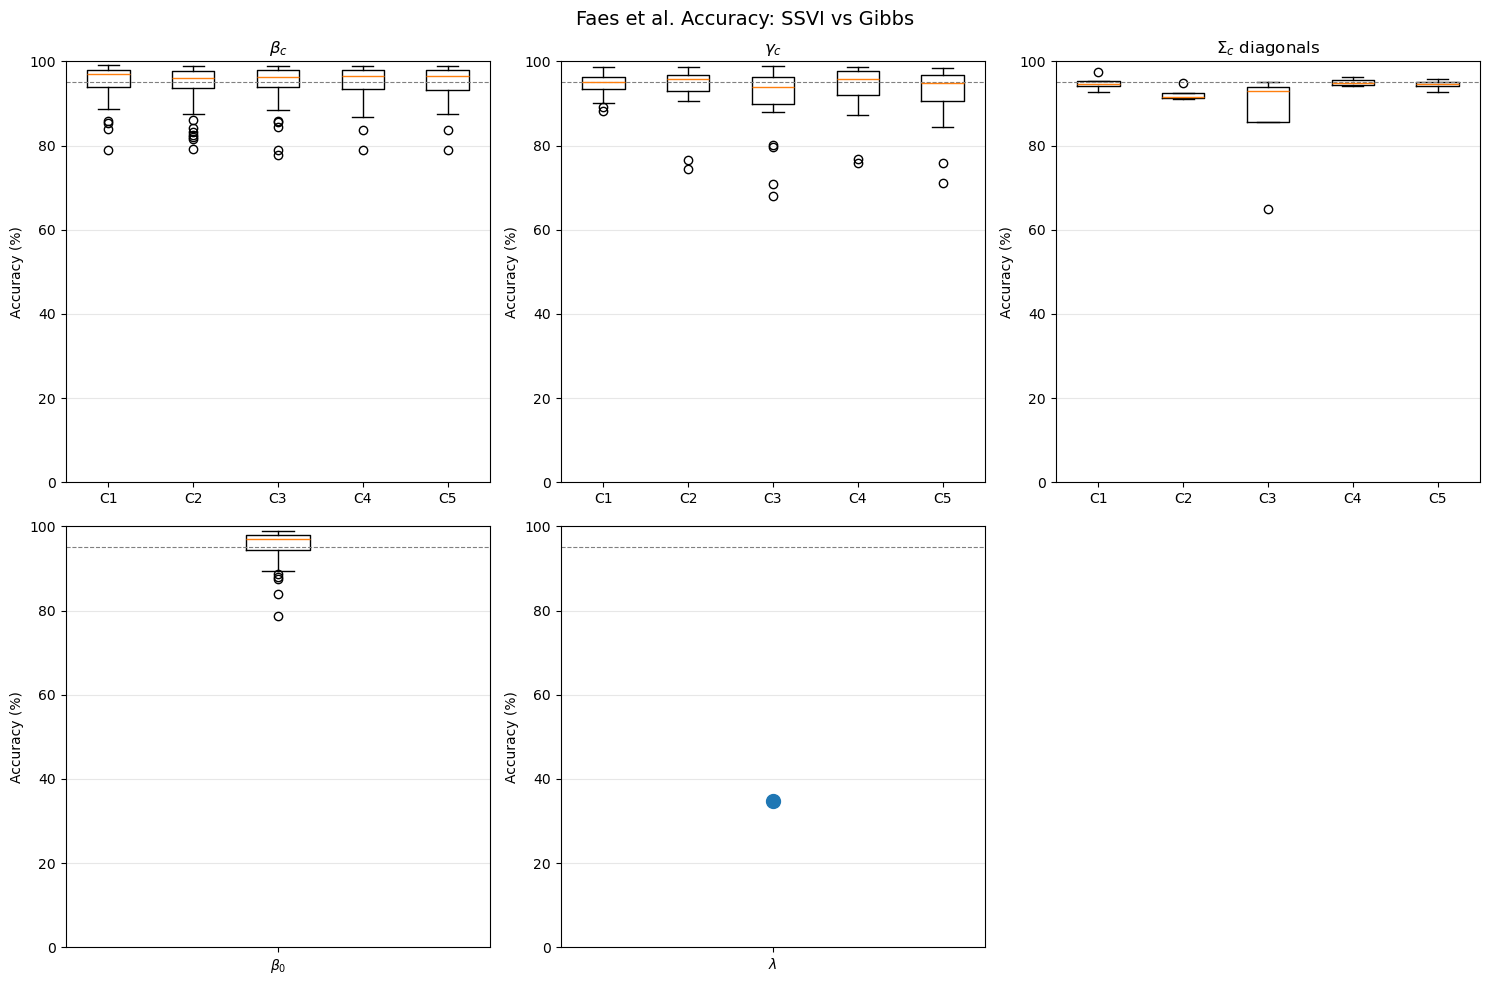

In [ ]:
"""Boxplots of Accuracy"""
plot_accuracy_boxplots(results_faes_ssvi_i, "SSVI-I", C)

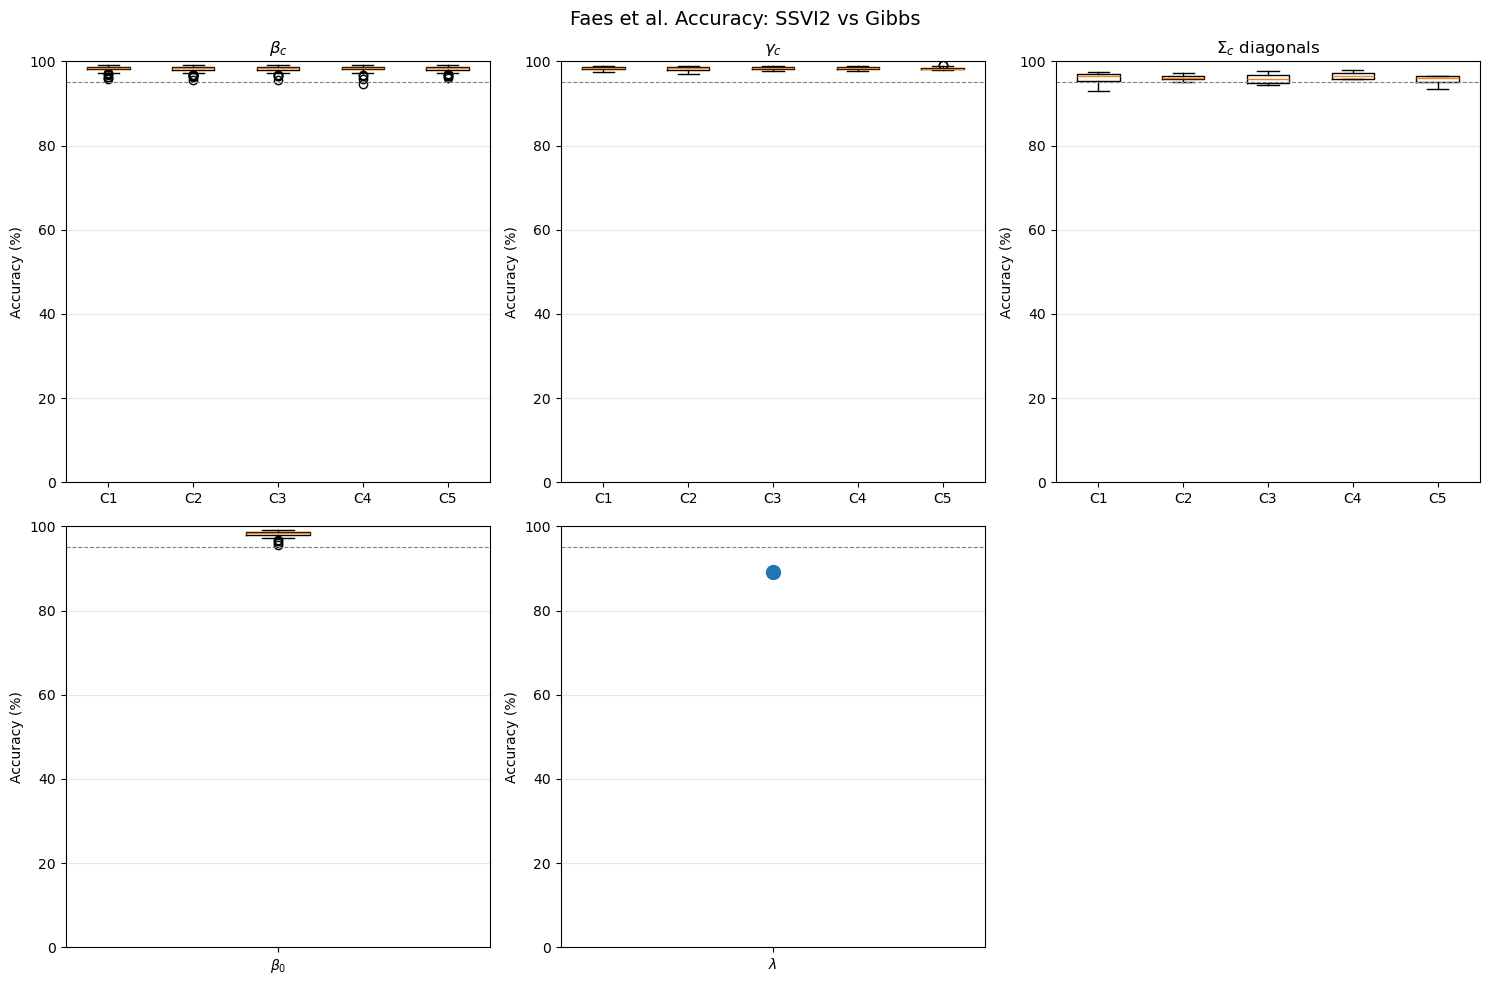

In [ ]:
"""Boxplots of Accuracy"""
plot_accuracy_boxplots(results_faes_ssvi_c, "SSVI-C", C)

In [ ]:
beta_mfvi  = np.array(mfvi_samples["beta_c"])
sigma_mfvi = np.array(mfvi_samples["Sigma_c"])

beta_ssvi_i  = np.array(ssvi_i_samples["beta_c"])
sigma_ssvi_i = np.array(ssvi_i_samples["Sigma_c"])

beta_ssvi_c  = np.array(ssvi_c_samples["beta_c"])
sigma_ssvi_c = np.array(ssvi_c_samples["Sigma_c"])

beta_gibbs  = np.array(results_gibbs["beta_c"])
sigma_gibbs = np.array(results_gibbs["Sigma_c"])

rng = np.random.default_rng(0)
n_draws = 10000
sign_pattern = ((2, 2, 1.0), (3, 2, -1.0), (2, 3, 1.0), (3, 3, 1.0))

idx_mfvi = rng.choice(beta_mfvi.shape[0], size=n_draws, replace=False)
irfs_mfvi, tries_mfvi = compute_irfs(
    beta_mfvi[idx_mfvi], sigma_mfvi[idx_mfvi],
    N=N, L=L, K=K, C=C, H=36, sign_pattern=sign_pattern, seed=1
)

idx_ssvi_i = rng.choice(beta_ssvi_i.shape[0], size=n_draws, replace=False)
irfs_ssvi_i, tries_ssvi_i = compute_irfs(
    beta_ssvi_i[idx_ssvi_i], sigma_ssvi_i[idx_ssvi_i],
    N=N, L=L, K=K, C=C, H=36, sign_pattern=sign_pattern, seed=2
)

idx_ssvi_c = rng.choice(beta_ssvi_c.shape[0], size=n_draws, replace=False)
irfs_ssvi_c, tries_ssvi_c = compute_irfs(
    beta_ssvi_c[idx_ssvi_c], sigma_ssvi_c[idx_ssvi_c],
    N=N, L=L, K=K, C=C, H=36, sign_pattern=sign_pattern, seed=3
)

idx_gibbs = rng.choice(beta_gibbs.shape[0], size=n_draws, replace=False)
irfs_gibbs, tries_gibbs = compute_irfs(
    beta_gibbs[idx_gibbs], sigma_gibbs[idx_gibbs],
    N=N, L=L, K=K, C=C, H=36, sign_pattern=sign_pattern, seed=4
)

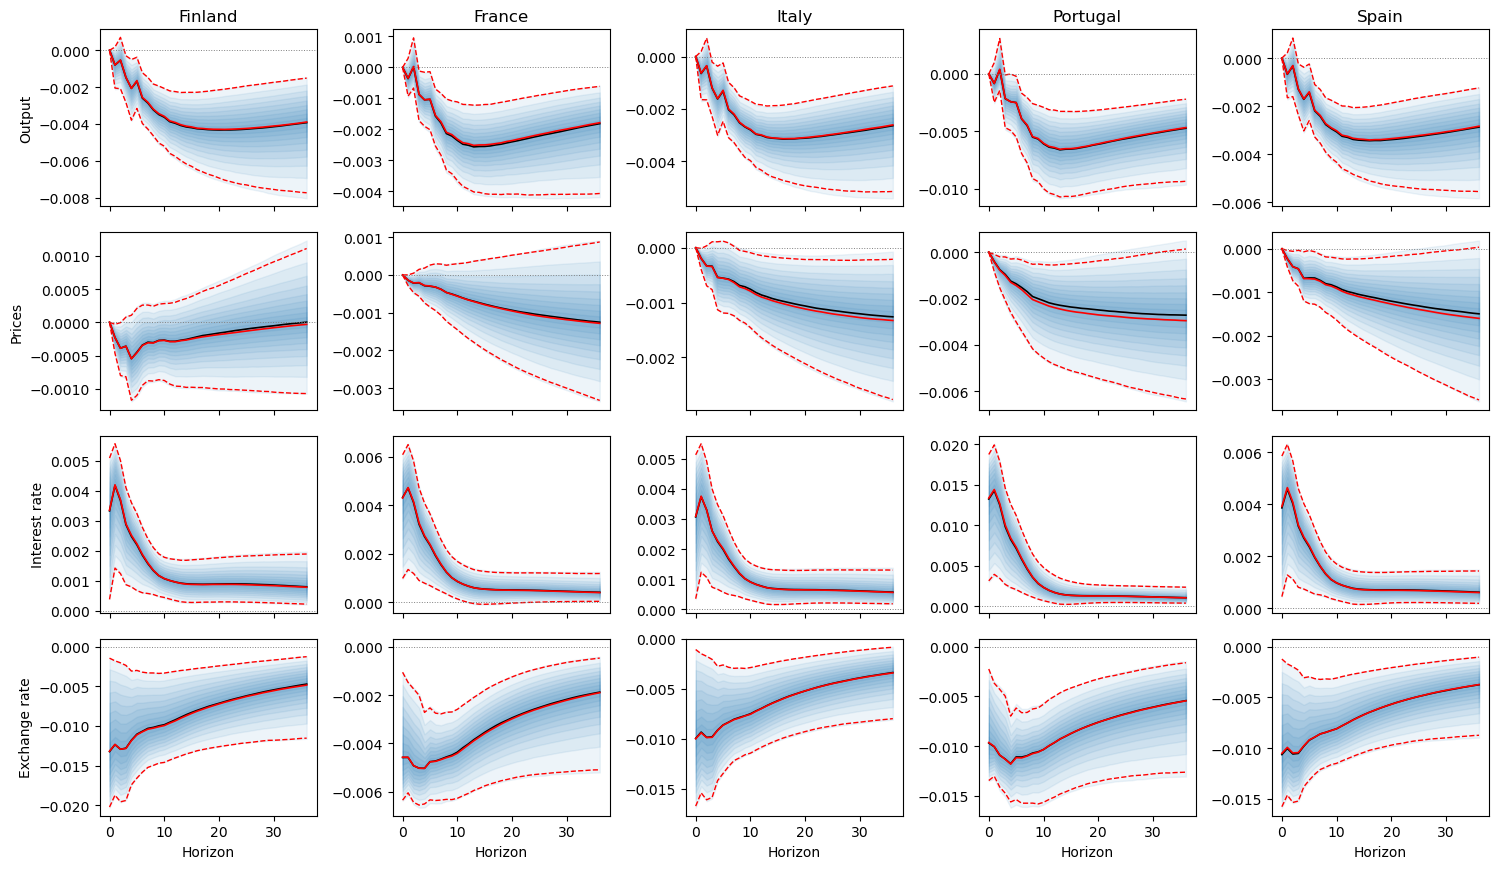

In [ ]:
country_names = ["Finland", "France", "Italy","Portugal", "Spain"]
variable_names = ["Output", "Prices", "Interest rate", "Exchange rate"]

plot_irfs_comparison(irfs_gibbs, irfs_mfvi, country_names, variable_names, vi_label="MFVI")

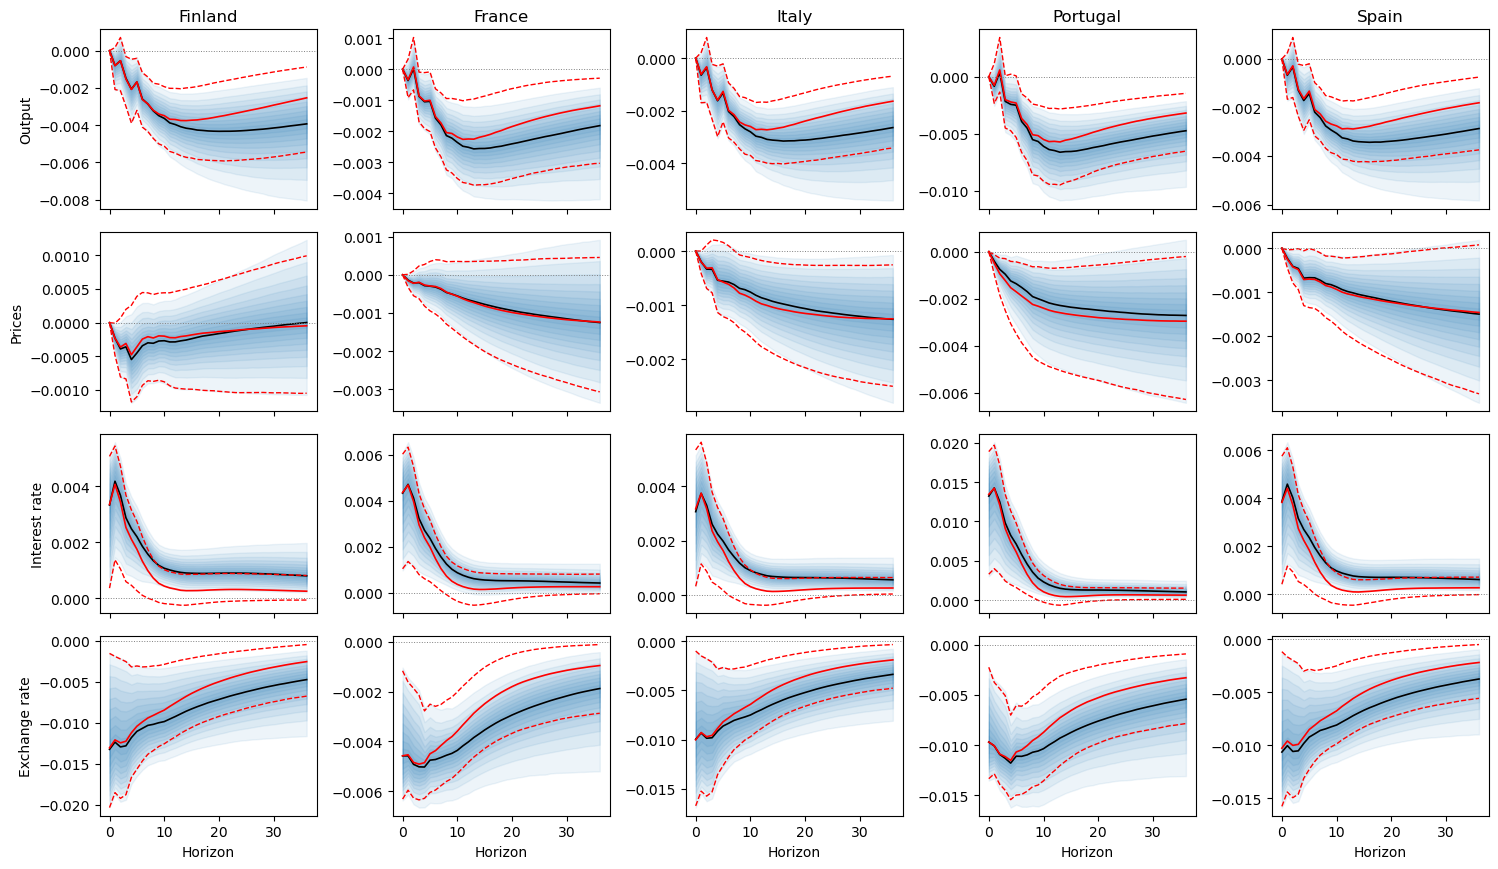

In [ ]:
plot_irfs_comparison(irfs_gibbs, irfs_ssvi_i, country_names, variable_names, vi_label="SSVI-I")

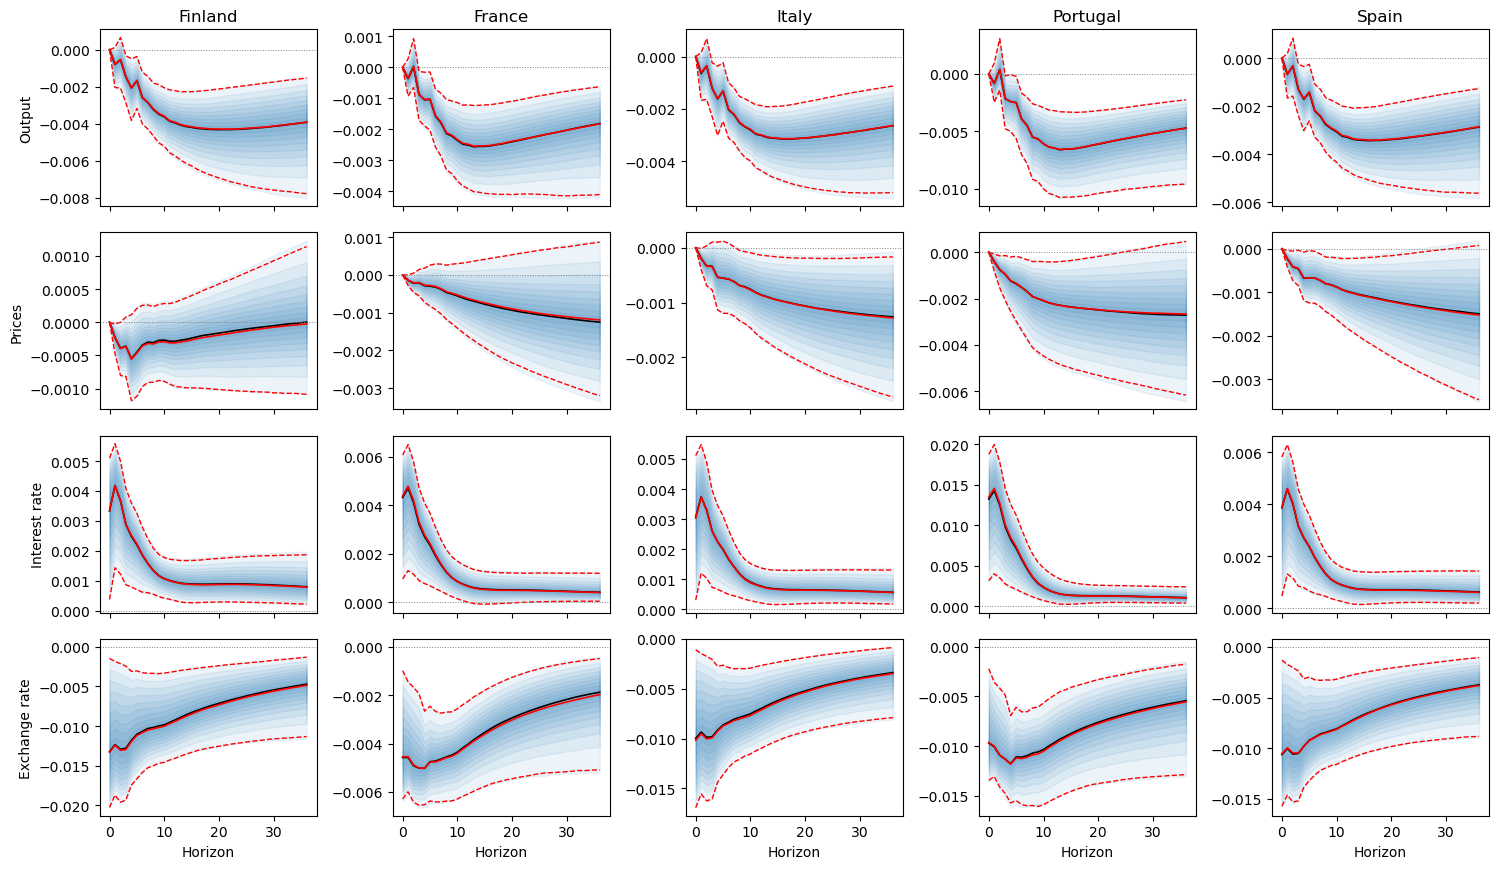

In [ ]:
plot_irfs_comparison(irfs_gibbs, irfs_ssvi_c, country_names, variable_names, vi_label="SSVI-C")

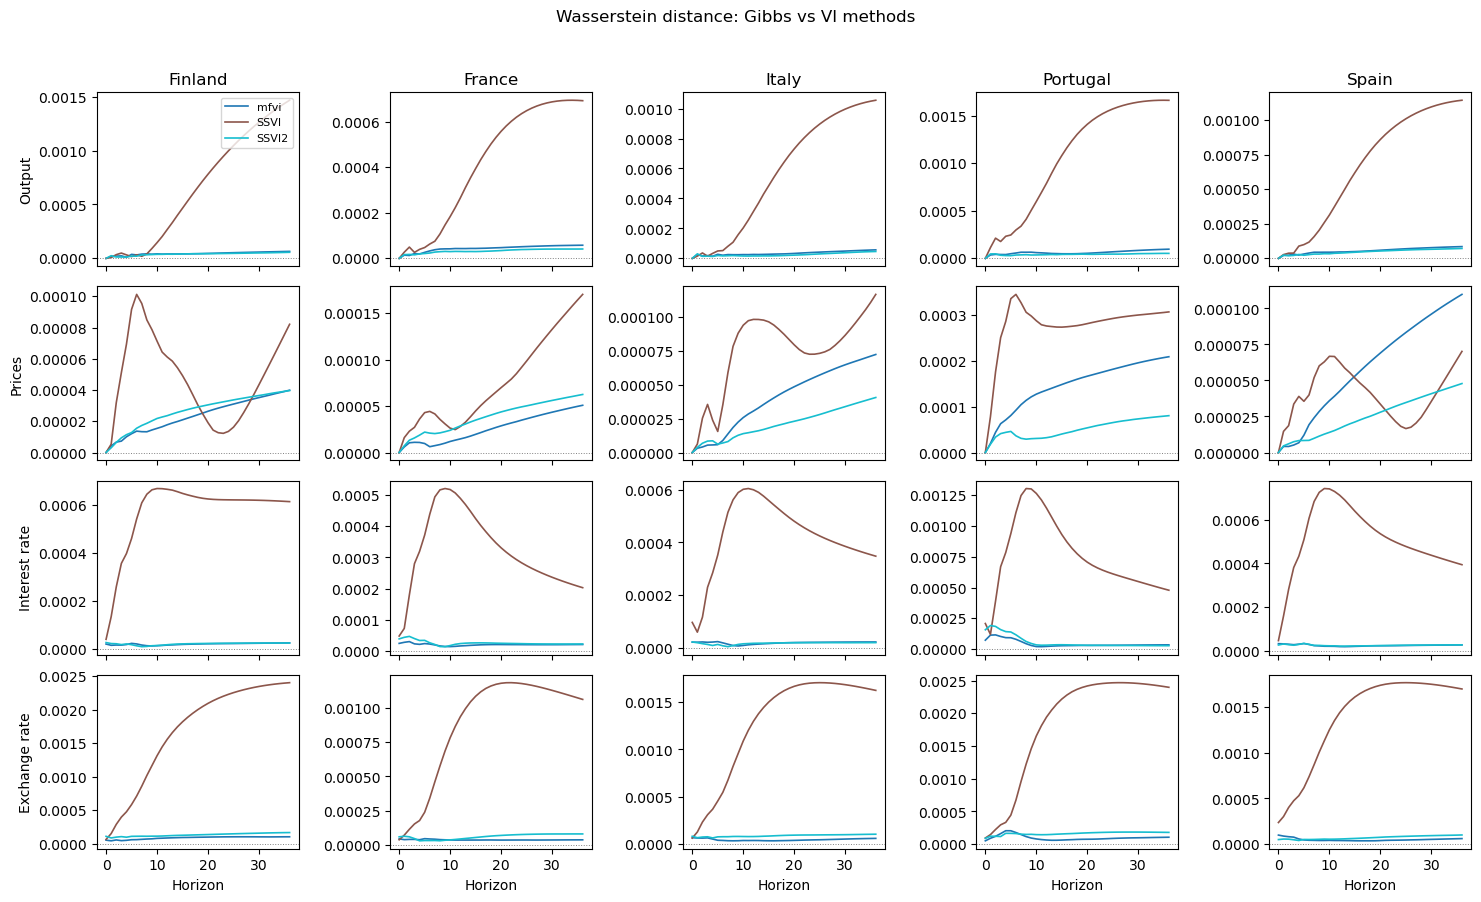

In [ ]:
wass_mfvi = compute_wasserstein_curve(irfs_gibbs, irfs_mfvi)
wass_ssvi_i = compute_wasserstein_curve(irfs_gibbs, irfs_ssvi_i)
wass_ssvi_c = compute_wasserstein_curve(irfs_gibbs, irfs_ssvi_c)

plot_wasserstein_grid_comparison(
    {"mfvi": wass_mfvi, "SSVI_I": wass_ssvi_i, "SSVI_C": wass_ssvi_c},
    country_names, variable_names
)